In [1]:
# import libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import PolynomialFeatures , StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score , mean_squared_error
from sklearn.pipeline import Pipeline

In [2]:
# create Dataset.

np.random.seed(42)

x = 6 * np.random.rand(200)
y =  0.5 *x**3 -x**2+2*x + np.random.randn(200)

# convert the dataframe.
data = pd.DataFrame({
    "feature_x": x,
    "target_y":y
})

data.head()

,feature_x,target_y
0,2.247241,4.438751
1,5.704286,71.907476
2,4.391964,32.146705
3,3.591951,16.739314
4,0.936112,3.271853


In [5]:
# feature & target split

# make sure features are 2D (DataFrame) so sklearn transformers work correctly
x = data[["feature_x"]]  # double brackets keep it as DataFrame
y = data["target_y"]

# train test split

x_train, x_test , y_train , y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# build ml pipeline

model_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("poly_feature",PolynomialFeatures(degree=3)),
    ("regression",LinearRegression())

])

# model training

model_pipeline.fit(x_train,y_train)

# prediction

y_pred = model_pipeline.predict(x_test)

# model evaluation.

r2 = r2_score(y_test,y_pred)
print("r2_score",r2)

print("mean squared error:",mean_squared_error(y_test,y_pred))



r2_score 0.9978878179928959
mean squared error: 1.103581153071357


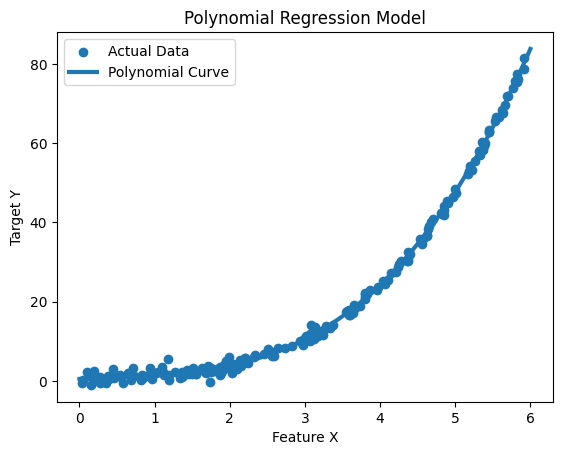

In [7]:
# Visualization


X_plot = np.linspace(0,6,200)
X_plot_df = pd.DataFrame({"feature_x": X_plot})

y_plot = model_pipeline.predict(X_plot_df)

plt.scatter(data["feature_x"], data["target_y"], label="Actual Data")
plt.plot(X_plot, y_plot, linewidth=3, label="Polynomial Curve")

plt.xlabel("Feature X")
plt.ylabel("Target Y")
plt.title("Polynomial Regression Model")
plt.legend()

plt.show()